# Spectral Data Preprocessing

This notebook preprocesses original `.spect` data files to convert discrete data into smooth upper envelope curves along the peaks of the data.

## Usage Guide

1. **Setup**: Modify the `filename` variable in Cell 1 to specify which `.spect` file to process
2. **Load Data**: Run Cell 2 to load the spectral data
3. **Apply Smoothing**: Run Cell 3 to apply upper envelope smoothing (adjust parameters as needed)
4. **Visualize**: Run Cell 4 to visualize the original vs smoothed data
5. **Save (Optional)**: Run Cell 5 to save the preprocessed data (skip if not needed)
6. **Manual Adjustment**: If you manually edit the smoothed data, use Cells 6-8 to visualize and save

## Data Format

- Input: `.spect` files with tab-separated values
  - Column 1: Intensity
  - Column 2: (ignored)
  - Column 3: Wavelength
- Output: `*_smoothed.txt` files with tab-separated values
  - Column 1: Wavelength
  - Column 2: Envelope Intensity


## Step 1: Setup and Configuration

Set up the environment and specify the data file to process.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Add parent directory to path for importing data_process modules
sys.path.insert(0, os.path.abspath('..'))

# ===== Configuration =====
# Modify the filename below to process different .spect files
filename = "1360-1800-5-4.spect"
data_dir = "../data/Vera0925"
file_path = os.path.join(data_dir, filename)


## Step 2: Load Data

Load the `.spect` file and extract intensity and wavelength data.


In [2]:
# Load .spect file
data = np.loadtxt(file_path)

# Extract data columns:
# Column 0: Intensity
# Column 1: (ignored)
# Column 2: Wavelength
intensity = data[:, 0]
wavelength = data[:, 2]

print(f"File name: {filename}")
print(f"Number of data points: {len(wavelength)}")
print(f"Wavelength range: {wavelength.min():.1f} - {wavelength.max():.1f}")
print(f"Intensity range: {intensity.min():.6e} - {intensity.max():.6e}")


File name: 1360-1800-5-4.spect
Number of data points: 441
Wavelength range: 1359.0 - 1799.0
Intensity range: 2.499209e-07 - 2.900000e-04


## Step 3: Apply Upper Envelope Smoothing

Apply upper envelope smoothing to create a smooth curve along the peaks of the data.

### Parameters

- **`peak_distance`**: Minimum distance between peaks (smaller = more peaks, more details)
- **`min_prominence`**: Peak detection sensitivity (lower = more peaks detected)
- **`local_smooth`**: Local smoothing window (must be odd, smaller = more details preserved)

**Adjust these parameters to optimize the envelope smoothness vs detail preservation.**


In [3]:
# Import upper envelope smoothing function
from data_process.preprocessor import upper_envelope_smooth

# ===== Smoothing Parameters =====
# Adjust these parameters to control the smoothness vs detail preservation
peak_distance = 1        # Minimum distance between peaks (smaller = more peaks, more details)
min_prominence = 0.1     # Peak detection sensitivity (lower = more peaks detected)
local_smooth = 3         # Local smoothing window (must be odd, smaller = more details preserved)

# Apply upper envelope smoothing
intensity_smooth = upper_envelope_smooth(intensity, wavelength, 
                                        peak_distance=peak_distance,
                                        min_prominence_ratio=min_prominence,
                                        local_window=local_smooth)

print(f"Original intensity range: {intensity.min():.6e} - {intensity.max():.6e}")
print(f"Envelope intensity range: {intensity_smooth.min():.6e} - {intensity_smooth.max():.6e}")


Original intensity range: 2.499209e-07 - 2.900000e-04
Envelope intensity range: 1.338534e-06 - 2.999811e-04


## Step 3.5: Iterative Smoothing (Optional)

If the initial envelope is too close to the data, apply iterative smoothing to achieve a smoother result.

**Adjust `num_iterations` to control the level of smoothness.**

In [348]:
# ===== Iterative Smoothing Parameters =====
# Set num_iterations to 0 to skip iterative smoothing
num_iterations = 1  # Number of times to apply smoothing (0 = skip, 1-5 recommended)

# Parameters for iterative smoothing (can be different from initial smoothing)
# For iterations, you may want to use larger windows for more smoothing
iter_peak_distance = 1# max(peak_distance, 3)  # Larger distance = fewer peaks = smoother
iter_min_prominence = 0.1 # min_prominence * 1.5  # Higher threshold = fewer peaks = smoother  
iter_local_smooth = 3# max(local_smooth, 5)    # Larger window = smoother
if iter_local_smooth % 2 == 0:
    iter_local_smooth += 1  # Ensure odd

# Apply iterative smoothing
if num_iterations > 0:
    print(f"Applying {num_iterations} iterations of smoothing...")
    current_envelope = intensity_smooth.copy()
    
    for i in range(num_iterations):
        # Apply smoothing to the current envelope
        # The envelope should still be constrained to be >= original data
        current_envelope = upper_envelope_smooth(current_envelope, wavelength,
                                                peak_distance=iter_peak_distance,
                                                min_prominence_ratio=iter_min_prominence,
                                                local_window=iter_local_smooth)
        
        # Ensure it's still above original data (critical constraint)
        current_envelope = np.maximum(current_envelope, intensity)
        
        print(f"  Iteration {i+1}/{num_iterations} complete")
    
    intensity_smooth = current_envelope
    print(f"\nIterative smoothing complete!")
    print(f"Final envelope intensity range: {intensity_smooth.min():.6e} - {intensity_smooth.max():.6e}")
else:
    print("Iterative smoothing skipped (num_iterations = 0)")

Applying 1 iterations of smoothing...
  Iteration 1/1 complete

Iterative smoothing complete!
Final envelope intensity range: 1.399163e-06 - 3.005032e-04


## Step 3.6: Pure Smoothing (Final Step)

Apply pure smoothing to the envelope without any peak detection.
This step only smooths the existing envelope to remove remaining roughness.

In [5]:
# ===== Multiple Pure Smoothing Passes =====
num_smoothing_passes = 100  # Number of times to apply pure smoothing
smoothing_window = 15
smoothing_polyorder = 3

if num_smoothing_passes > 0:
    from scipy.signal import savgol_filter
    
    if smoothing_window % 2 == 0:
        smoothing_window += 1
    smoothing_window = min(smoothing_window, len(intensity_smooth) - 1)
    if smoothing_window % 2 == 0:
        smoothing_window -= 1
    
    print(f"Applying {num_smoothing_passes} passes of pure smoothing...")
    
    for i in range(num_smoothing_passes):
        intensity_smooth_smoothed = savgol_filter(intensity_smooth,
                                                 window_length=smoothing_window,
                                                 polyorder=smoothing_polyorder)
        
        # Only use where it's valid
        valid_mask = intensity_smooth_smoothed >= intensity
        intensity_smooth = np.where(valid_mask, intensity_smooth_smoothed, intensity_smooth)
        intensity_smooth = np.maximum(intensity_smooth, intensity)
        
        print(f"  Smoothing pass {i+1}/{num_smoothing_passes} complete")
    
    print(f"Final envelope range: {intensity_smooth.min():.6e} - {intensity_smooth.max():.6e}")

Applying 100 passes of pure smoothing...
  Smoothing pass 1/100 complete
  Smoothing pass 2/100 complete
  Smoothing pass 3/100 complete
  Smoothing pass 4/100 complete
  Smoothing pass 5/100 complete
  Smoothing pass 6/100 complete
  Smoothing pass 7/100 complete
  Smoothing pass 8/100 complete
  Smoothing pass 9/100 complete
  Smoothing pass 10/100 complete
  Smoothing pass 11/100 complete
  Smoothing pass 12/100 complete
  Smoothing pass 13/100 complete
  Smoothing pass 14/100 complete
  Smoothing pass 15/100 complete
  Smoothing pass 16/100 complete
  Smoothing pass 17/100 complete
  Smoothing pass 18/100 complete
  Smoothing pass 19/100 complete
  Smoothing pass 20/100 complete
  Smoothing pass 21/100 complete
  Smoothing pass 22/100 complete
  Smoothing pass 23/100 complete
  Smoothing pass 24/100 complete
  Smoothing pass 25/100 complete
  Smoothing pass 26/100 complete
  Smoothing pass 27/100 complete
  Smoothing pass 28/100 complete
  Smoothing pass 29/100 complete
  Smoothing

## Step 4: Visualize Results

Compare the original discrete data with the smoothed upper envelope curve.


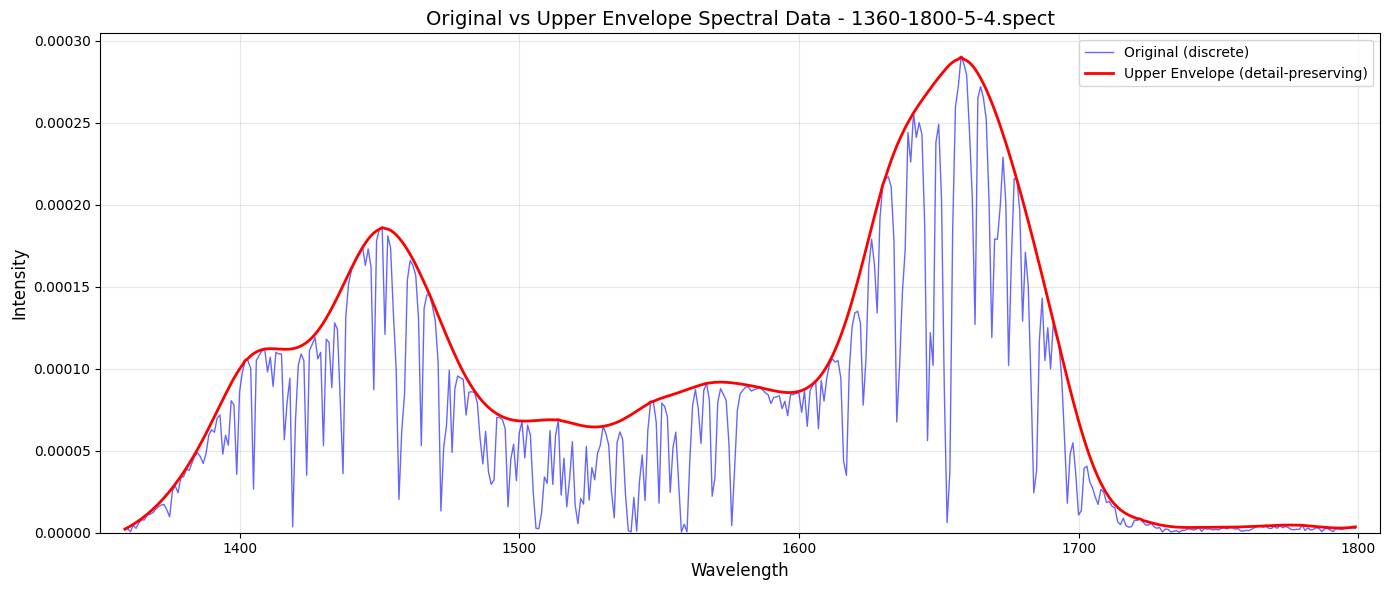

In [6]:
# Create visualization comparing original and smoothed data
fig = plt.figure(figsize=(14, 6))

plt.plot(wavelength, intensity, 'b-', linewidth=1, alpha=0.6, label='Original (discrete)')
plt.plot(wavelength, intensity_smooth, 'r-', linewidth=2, label='Upper Envelope (detail-preserving)')

# Set axis limits based on data range (with small margin)
wavelength_margin = (wavelength.max() - wavelength.min()) * 0.02
intensity_margin = (intensity.max() - intensity.min()) * 0.05
plt.xlim(wavelength.min() - wavelength_margin, wavelength.max() + wavelength_margin)
plt.ylim(max(0, intensity.min() - intensity_margin), intensity.max() + intensity_margin)

plt.xlabel('Wavelength', fontsize=12)
plt.ylabel('Intensity', fontsize=12)
plt.title(f'Original vs Upper Envelope Spectral Data - {filename}', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 5: Save Preprocessed Data (Optional)

**Run this cell to save the preprocessed data, or skip if you don't want to save.**

The processed data will be saved to `{data_dir}/preprocessed/{filename}_smoothed.txt`


In [7]:
# Save preprocessed data
# NOTE: Run this cell to save, or skip if you don't want to save

# Setup output directory
output_dir = os.path.join(data_dir, "preprocessed")
os.makedirs(output_dir, exist_ok=True)

# Prepare save path
base_filename = os.path.splitext(filename)[0]
save_path = os.path.join(output_dir, f"{base_filename}_smoothed.txt")

# Save data: wavelength (column 1), envelope_intensity (column 2)
# Using scientific notation for better precision
data_to_save = np.column_stack((wavelength, intensity_smooth))
np.savetxt(save_path, data_to_save, fmt=['%.1f', '%.10e'], delimiter='\t',
           header='Wavelength\tEnvelope_Intensity', comments='')

print(f"Processed data saved to: {save_path}")
print(f"Data shape: {data_to_save.shape}")


Processed data saved to: ../data/Vera0925/preprocessed/1360-1800-5-4_smoothed.txt
Data shape: (441, 2)


## Step 6: Manual Adjustment (Optional)

If you need to manually adjust the smoothed data, edit the file in the `manually` folder and then continue with the cells below.

Placeholder for manual data adjustment
If you manually edit the smoothed data file, it should be saved in:
{data_dir}/manually/{filename}_smoothed.txt
Then proceed to the next cells to visualize and save the plot

## Step 7: Load and Visualize Manually Adjusted Data

Load the manually adjusted envelope data (if available) and visualize it.


Loaded manually adjusted envelope data: 441 points
Wavelength range: 1359.0 - 1799.0
Intensity range: 2.210026e-06 - 2.900000e-04


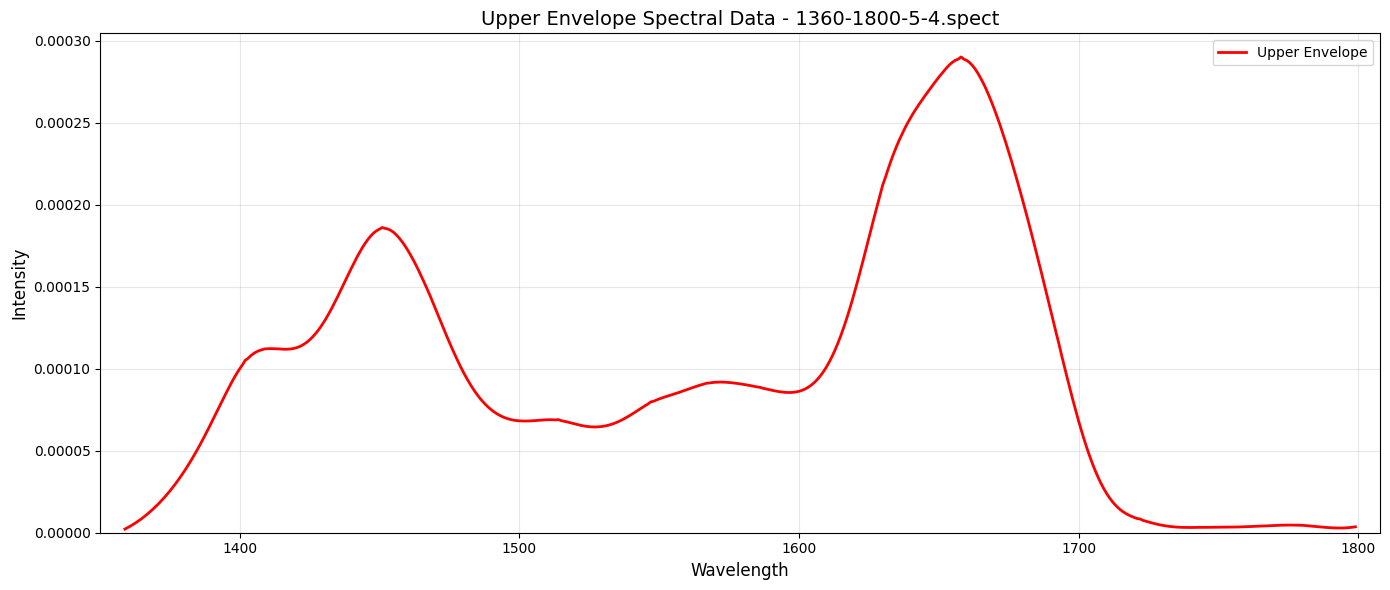

In [8]:
# Load manually adjusted envelope data
manually_dir = os.path.join(data_dir, "preprocessed")
smoothed_file = os.path.join(manually_dir, f"{base_filename}_smoothed.txt")
smoothed_data = np.loadtxt(smoothed_file, skiprows=1)  # Skip header row

# Extract data
wavelength_loaded = smoothed_data[:, 0]
intensity_loaded = smoothed_data[:, 1]

print(f"Loaded manually adjusted envelope data: {len(wavelength_loaded)} points")
print(f"Wavelength range: {wavelength_loaded.min():.1f} - {wavelength_loaded.max():.1f}")
print(f"Intensity range: {intensity_loaded.min():.6e} - {intensity_loaded.max():.6e}")

# Visualize the manually adjusted envelope data
fig = plt.figure(figsize=(14, 6))

plt.plot(wavelength_loaded, intensity_loaded, 'r-', linewidth=2, label='Upper Envelope')

# Set axis limits based on data range (with small margin)
wavelength_margin = (wavelength_loaded.max() - wavelength_loaded.min()) * 0.02
intensity_margin = (intensity_loaded.max() - intensity_loaded.min()) * 0.05
plt.xlim(wavelength_loaded.min() - wavelength_margin, wavelength_loaded.max() + wavelength_margin)
plt.ylim(max(0, intensity_loaded.min() - intensity_margin), intensity_loaded.max() + intensity_margin)

plt.xlabel('Wavelength', fontsize=12)
plt.ylabel('Intensity', fontsize=12)
plt.title(f'Upper Envelope Spectral Data - {filename}', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Step 8: Save Visualization Plot (Optional)

**Run this cell to save the plot, or skip if you don't want to save.**

The plot will be saved to `{data_dir}/plot/{filename}_smoothed.png`


In [9]:
# Save the visualization plot

# Setup plot output directory
plot_dir = os.path.join(data_dir, "preprocessed/plot")
os.makedirs(plot_dir, exist_ok=True)

# Save plot
save_plot_path = os.path.join(plot_dir, f"{base_filename}_smoothed.png")
fig.savefig(save_plot_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {save_plot_path}")


Plot saved to: ../data/Vera0925/preprocessed/plot/1360-1800-5-4_smoothed.png
